# **Tutorial Optimizer Prosumer**
This tutorial demonstrates how to run a multi-objective sizing optimisation for a prosumer (production system + BESS) from the `tutorials/example_model/ProsumerOptimizer` folder in the pyRES package.

The tutorial walks through the script `main.py` step by step and shows how to:

1. Load the input data (demand curve and normalised production) from a CSV file.

2. Define the `System` and `Bess` unit templates that the optimiser scales by integer multiples.

3. Configure the economic parameters of the prosumer.

4. Instantiate and run the `ProsumerOptimizer` (NSGA-II) and analyse the Pareto front.

5. Save the diagnostic plots (Pareto front and convergence) in the `Output/` folder.

----
---

## **Example model Structure**

Below is the structure of the ProsumerOptimizer example located in
`tutorials/example_model/`

```bash
ProsumerOptimizer/
│
├── Input/
│   └── prod_and_dem_kW.csv
│
├── Output/
│   ├── pareto.png
│   └── convergence.png
│
└── main.py
```

`main.py` reads the input curves from `Input/prod_and_dem_kW.csv`, runs a quick NSGA-II optimisation to size the PV and BESS of a single prosumer, and saves the diagnostic plots in `Output/`.

---
---

## **Step 1 - Setup**

Locate the project root so that `from src...` imports work regardless of the launch directory, and import the classes used by the optimiser:
- `System` — base production system, used as the unit template for PV.
- `Bess` — battery energy storage, used as the unit template for BESS.
- `ProsumerOptimizer` — multi-objective NSGA-II sizing optimiser.

We also define `example_dir` as the path to the `ProsumerOptimizer/` folder, used later to locate the CSV input and the Output folder.

In [1]:
import os, sys
from pathlib import Path

# Find project root (works from any launch directory)
root = Path.cwd()
while not (root / 'src').is_dir() and root != root.parent:
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
import matplotlib.pyplot as plt

from src.rec_sim.System import System
from src.rec_sim.Bess import Bess
from src.optimizer.optimizer_prosumer import ProsumerOptimizer

example_dir = Path('tutorials/example_model/ProsumerOptimizer')

---
---

## **Step 2 - Set Input**

All inputs of the optimisation are grouped in a single block, mirroring the `# --- Set input ---` section of `main.py`:

- **Simulation settings**: time step and investment horizon.
- **PV unit parameters**: collected in the `pv` dictionary (one kWp per unit).
- **BESS unit parameters**: collected in the `bess` dictionary (one battery module per unit).
- **Demand and production curves**: loaded from `Input/prod_and_dem_kW.csv` (two `;`-separated columns).

Defining the PV and BESS inputs as plain dictionaries keeps all the settings you may want to change in one place; Steps 3 and 4 will then simply unpack these dictionaries into the `System` and `Bess` constructors.

In [2]:
# --- Simulation settings ---
time_step = 0.25       # hours (15-min step)
time_horizon = 20      # years (NPV investment horizon)
n_system_max = 20
n_bess_max = 10
pop_size = 40
mode = 'system_and_bess'
objective_function = 'self_consumption'
n_gen = 15

# --- PV unit parameters ---
pv = {
    'cap': 1,             # 1 kWp per unit
    'cap_cost': 1000,
    'opex': 1.0, 'opex_cost': 40,
    'inc_year': 0, 'inc_start_end': [0, 0], 'tax_year': 0,
}

# --- BESS unit parameters ---
bess = {
    'cap': 2.56,          # 2.56 kWh per unit
    'c_rate': 1.0,
    'soc_in': 0.2, 'soc_max': 0.8, 'soc_min': 0.2,
    'eta_charge': 0.95, 'eta_discharge': 0.95,
    'self_discharge_rate_per_hour': 4e-5,
    'lifetime_years': 15,
    'cap_cost': 450, 'opex_cost': 20,
    'inc_year': 0, 'inc_start_end': [0, 0], 'tax_year': 0,
}

prosumer_economics = {
    'tax_rate': 0.2,
    'int_rate': 0.05,
    'price_buy': 250,
    'price_sold': 104,
    'decay': 0.02,
    'other_capex_perc': [0],
}

**Simulation settings:**
- `time_step` = 0.25 h → 15-minute resolution (same convention used everywhere in pyRES). Must match the row spacing of the CSV.
- `time_horizon` = 20 y → investment horizon used to compute the NPV.

**Mode and objective functions:**
- `mode='system_and_bess'`: both PV size (`n_system`) and BESS size (`n_bess`) are decision variables. Use `'bess_only'` to fix the PV at the template size and optimise only the battery.
- `objective_function='self_consumption'`: maximise self-consumption [MWh/y] vs NPV. Use `'self_sufficiency'` to maximise the demand fraction covered locally.

**Bounds on the decision variables:**
- `n_system_max=20`: maximum 20 × 1 kWp = 20 kWp of PV.
- `n_bess_max=10`: maximum 10 × 2.56 kWh = 25.6 kWh of BESS.

**NSGA-II settings:**
- `pop_size=40`: number of individuals per generation.
- `n_gen=15`: maximum number of generations (early stopping via the default multi-objective termination criterion may halt earlier).

**Keys of the `pv` dictionary** (one PV unit = 1 kWp):
- `cap`: installed capacity of a single unit (kWp). Here 1 kWp.
- `cap_cost`: capital cost per unit of capacity (€/kWp). Here 1000 €/kWp.
- `opex`: operating quantity used to compute OPEX. With `opex=cap`, OPEX scales with installed capacity.
- `opex_cost`: annual O&M cost (€/kW/y). Here 40 €/kW/y.
- `inc_year`: incentive value per year (€/y). Set to 0 (no incentives).
- `inc_start_end`: start/end year of the incentive window.
- `tax_year`: fixed annual tax (€/y).

**Keys of the `bess` dictionary** (one BESS unit = 2.56 kWh):
- `cap`: capacity of a single battery module (kWh).
- `c_rate`: C-rate defining max charge/discharge power (`P_max = cap * c_rate`).
- `soc_in`: initial state of charge (fraction of `cap`).
- `soc_max`, `soc_min`: SOC upper/lower bounds.
- `eta_charge`, `eta_discharge`: round-trip efficiencies (0–1, typical 0.92–0.97).
- `self_discharge_rate_per_hour`: passive SOC decay per hour (4e-5 ≈ 3 %/month for Li-ion).
- `lifetime_years`: battery lifetime in years (replacement cost is added if `lifetime < time_horizon`).
- `cap_cost`: capital cost per kWh (€/kWh).
- `opex_cost`: annual O&M cost (€/kWh/y).
- `inc_year`, `inc_start_end`, `tax_year`: incentives and taxes, same convention as the PV dictionary.

**P** (one BESS unit = 2.56 kWh):
- `tax_rate`: tax on revenues from energy sales (e.g. 0.2 → 20 %).
- `int_rate`: discount rate used for the NPV calculation (e.g. 0.05 → 5 %).
- `price_buy`: price of electricity purchased from the grid (€/MWh).
- `price_sold`: price of electricity sold to the grid (€/MWh).
- `decay`: annual fractional decay of energy prices (e.g. 0.02 → −2 %/year).
- `other_capex_perc`: list of additional CAPEX percentages applied to the upfront investment (e.g. [0] means no extra CAPEX, [0.2] means +20 %).





---
---

## **Step 3 - Import Demand and Normalized production**

In [3]:
csv_path = example_dir / 'Input' / 'prod_and_dem_kW.csv'
df = pd.read_csv(csv_path, delimiter=';')
prod_per_kwp = df['prod_per_kwp']
demand = df['demand']
print(df.head())

   prod_per_kwp  demand
0     28.376054     5.8
1     28.376054     5.8
2     28.376054     5.8
3     28.376054     5.8
4     28.376054     5.8


**Demand and production curves:**
- `prod_per_kwp`: production curve **per installed kWp** [kW/kWp]. The optimiser multiplies it by the total installed capacity for each candidate solution, so the CSV must already be normalised to 1 kWp.
- `demand`: load profile of the prosumer [kW].

> Note: both columns must have the same length and be aligned to the same `time_step`.

---
---

## **Step 4 - Build the PV Unit Template**

Instantiate the `System` object by unpacking the `pv` dictionary defined in Step 2. The template represents **one unit**; during the optimisation it will be scaled by an integer number of parallel units `n_system ∈ [1, n_system_max]`.

In [4]:
system_template = System(
    id='pv_unit', carriers=['electricity'],
    cap=pv['cap'],
    cap_cost=pv['cap_cost'],
    opex=pv['opex'], opex_cost=pv['opex_cost'],
    inc_year=pv['inc_year'], inc_start_end=pv['inc_start_end'], tax_year=pv['tax_year'],
)

`id` and `carriers` are passed directly to `System(...)` because they describe the object identity (string label and energy vectors), not numerical settings. All the remaining fields come from the `pv` dictionary defined in Step 2.

---
---

## **Step 5 - Build the BESS Unit Template**

Same pattern as Step 3: instantiate `Bess` by unpacking the `bess` dictionary defined in Step 2. The template represents **one battery module**; during the optimisation it is scaled by an integer number of parallel modules `n_bess ∈ [0, n_bess_max]`.

In [5]:
bess_template = Bess(
    id='bess_unit',
    cap=bess['cap'],
    c_rate=bess['c_rate'],
    soc_in=bess['soc_in'], soc_max=bess['soc_max'], soc_min=bess['soc_min'],
    eta_charge=bess['eta_charge'], eta_discharge=bess['eta_discharge'],
    self_discharge_rate_per_hour=bess['self_discharge_rate_per_hour'],
    lifetime_years=bess['lifetime_years'],
    cap_cost=bess['cap_cost'], opex_cost=bess['opex_cost'],
    inc_year=bess['inc_year'], inc_start_end=bess['inc_start_end'], tax_year=bess['tax_year'],
)

All numerical settings come from the `bess` dictionary defined in Step 2, so swapping out the battery chemistry, capacity or economic assumptions only requires changing values there — no edit is needed in this cell.

---
---

## **Step 6 - Instantiate the ProsumerOptimizer**

Pass the templates, the input curves and the optimisation settings. The two objectives minimised internally by NSGA-II are:

| Objective | Meaning |
|-----------|---------|
| `f1` | Negative self-consumption [MWh/y] (or negative self-sufficiency if `objective_function='self_sufficiency'`) |
| `f2` | Negative incremental NPV [€] (relative to the "all-from-grid" baseline) |

and the constraints (`g ≤ 0` is feasible):
- `g1`: prod/dem ≤ `max_prod_dem_ratio`
- `g2`: self_cons/dem ≥ `min_self_cons_ratio`
- `g3`: CAPEX ≤ `budget_max` (disabled when `budget_max=None`)

In [6]:
optimizer = ProsumerOptimizer(
    system=system_template,
    bess=bess_template,
    demand=demand,
    prod_per_kwp=prod_per_kwp,
    economics=prosumer_economics,
    time_step=time_step,
    time_horizon=time_horizon,
    mode=mode,
    objective_function=objective_function,
    n_system_max=n_system_max,
    n_bess_max=n_bess_max,
    pop_size=pop_size,
    n_gen=n_gen,
)

**Inputs:**
- `system`, `bess`: the unit templates defined in Steps 4 and 5.
- `demand`, `prod_per_kwp`: the time series loaded in Step 3.
- `economics`: the `prosumer_economics` dictionary defined in Step 2.

**Simulation settings:**
- `time_step`: must match the step used in the CSV (0.25 h) (defined in Step 2)
- `time_horizon`: investment horizon in years (e.g. 20 y) used for the NPV  (defined in Step 2)

**Mode and objective:**
- `mode='system_and_bess'`: both PV size (`n_system`) and BESS size (`n_bess`) are decision variables. Use `'bess_only'` to fix the PV at the template size and optimise only the battery.
- `objective_function='self_consumption'`: maximise self-consumption [MWh/y] vs NPV. Use `'self_sufficiency'` to maximise the demand fraction covered locally.

**Bounds on the decision variables:**
- `n_system_max=20`: maximum 20 × 1 kWp = 20 kWp of PV (defined in Step 2)
- `n_bess_max=10`: maximum 10 × 2.56 kWh = 25.6 kWh of BESS. (defined in Step 2)

**NSGA-II settings:**
- `pop_size=40`: number of individuals per generation. (defined in Step 2)
- `n_gen=15`: maximum number of generations (early stopping via the default multi-objective termination criterion may halt earlier). (defined in Step 2)

---
---

## **Step 7 - Run the Optimisation**

`summary()` prints the main configuration; `optimize()` runs NSGA-II and returns a DataFrame with the Pareto-front solutions sorted by the first objective.

In [7]:
optimizer.summary()
results = optimizer.optimize()
print('\nPareto front:')
print(results.to_string(index=False))

  ProsumerOptimizer — mode=system_and_bess, obj=self_consumption
  Time step:           0.25 h  (15 steps)
  Annual demand:       0.02 MWh
  System unit cap:     1.000 kW
  n_system_max:        20  (20.0 kW)
  BESS unit cap:       2.560 kWh
  n_bess_max:          10  (25.6 kWh)
  NSGA-II:             pop=40, gen=15
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       39 |      4 |  0.000000E+00 |  3.013366E+01 |             - |             -
     2 |       59 |      5 |  0.000000E+00 |  1.515413E+01 |  0.1870907832 |         ideal
     3 |       79 |      8 |  0.000000E+00 |  7.2132256227 |  0.0166138299 |             f
     4 |       99 |     13 |  0.000000E+00 |  1.0093547719 |  0.1111111111 |         ideal
     5 |      119 |     24 |  0.000000E+00 |  0.0129677386 |  0.0052981359 |             f
     6 |      139 |     38 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     7 |      159 |     40 |  0.000000E+00 |  

Columns of the returned `results` DataFrame:
- `n_system`, `n_bess`: integer number of PV/BESS units selected.
- `cap_system_kW`, `cap_bess_kWh`: total installed capacities.
- `capex_EUR`: total upfront capital cost.
- `self_cons_MWh` (or `self_sufficiency`): first objective — higher is better.
- `NPV_EUR`: incremental NPV relative to the "all-from-grid" baseline.

---
---

## **Step 8 - Inspect and Save the Results**

Two diagnostic plots are produced:
- `plot_pareto()`: Pareto front in the objective space (self-consumption or self-sufficiency vs NPV), coloured by installed PV capacity (left) and BESS capacity (right).
- `plot_convergence()`: normalised hypervolume across generations, useful to verify that the algorithm has converged.

Both methods return a `matplotlib.figure.Figure`, so we capture them and save each as a PNG in `Output/` (the folder is created automatically if it does not exist).

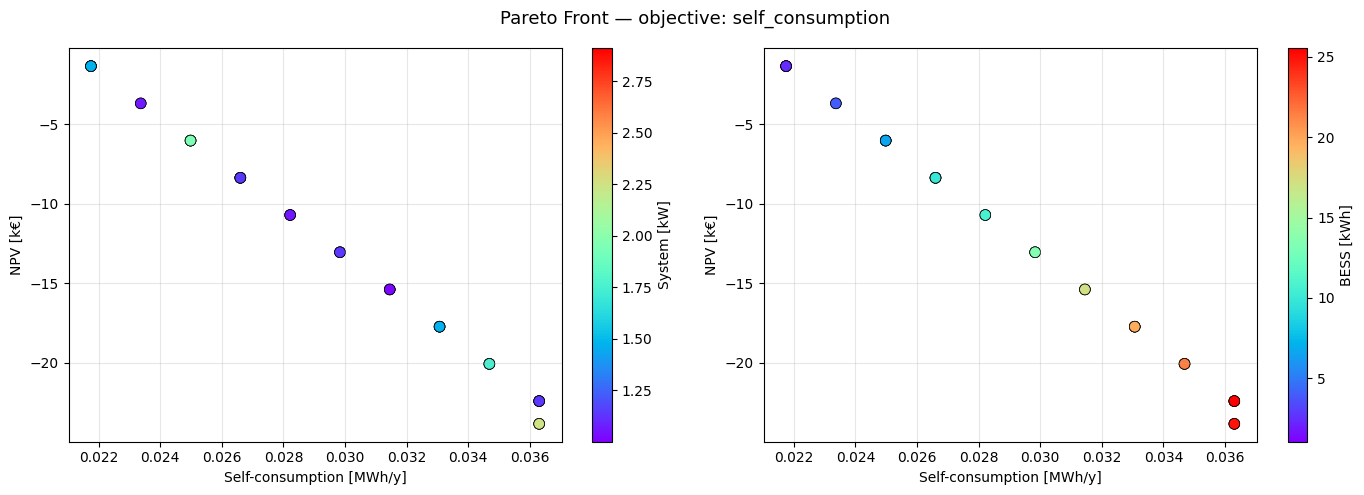

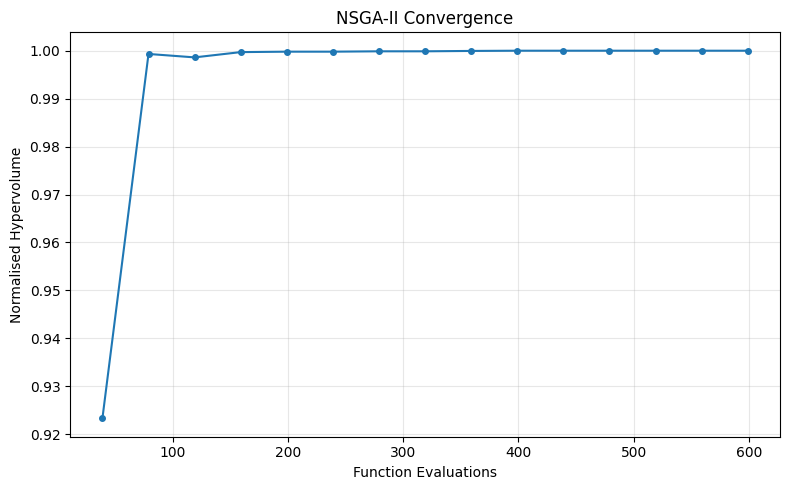

In [8]:
fig_pareto = optimizer.plot_pareto()
fig_convergence = optimizer.plot_convergence()

output_dir = example_dir / 'Output'
output_dir.mkdir(exist_ok=True)
fig_pareto.savefig(output_dir / 'pareto.png')
fig_convergence.savefig(output_dir / 'convergence.png')

plt.show()

Once a candidate is chosen from the Pareto front (e.g. the solution with the highest self-consumption that fits a given budget), the full time-series behaviour of that configuration can be reproduced with `optimizer.simulate_solution(n_system=..., n_bess=...)`, which returns the detailed energy flows, annual KPIs and economic performance of the corresponding `Prosumer`.

---
---